In [1]:
import numpy as np
import pandas as pd

## Data Understanding & Loading

In [2]:
rides = pd.read_csv("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_rides.csv")
drivers = pd.read_json("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_drivers.json")

In [3]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad
...,...,...,...,...,...,...
4995,4996,2.22,33.03,2026-04-06 17:46:54,Low,Ahmedabad
4996,4997,28.37,230.77,2026-03-29 10:46:54,Medium,Delhi
4997,4998,12.97,252.67,2026-03-16 20:46:54,Medium,Mumbai
4998,4999,10.41,197.99,2026-03-31 19:46:54,Low,Mumbai


In [4]:
rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      4754 non-null   float64
 2   fare_amount      4523 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    4737 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [5]:
drivers

,driver_id,experience,rating
0,1,14,3.98
1,2,14,2.77
2,3,8,4.95
3,4,8,2.61
4,5,13,2.66
...,...,...,...
195,196,5,4.69
196,197,3,4.61
197,198,1,4.02
198,199,13,4.75


In [6]:
drivers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   driver_id   200 non-null    int64  
 1   experience  200 non-null    int64  
 2   rating      200 non-null    float64
dtypes: float64(1), int64(2)
memory usage: 4.8 KB


## Data Cleaning

In [7]:
# Handle missing values in:
  # distance_km
  # fare_amount
  # traffic_level
# Decide appropriate strategies:
  # Mean / Median for numerical
  # Most frequent for categorical
# Convert pickup_datetime into proper datetime format
# Remove duplicate records
# Fix inconsistent values (if any)


In [8]:
rides[['distance_km', 'fare_amount', 'traffic_level']].isnull().sum()

,0
distance_km,246
fare_amount,477
traffic_level,263


In [9]:
rides[['distance_km', 'fare_amount', 'traffic_level']].dtypes

,0
distance_km,float64
fare_amount,float64
traffic_level,object


0.009735968310441857


<Axes: xlabel='distance_km', ylabel='Count'>

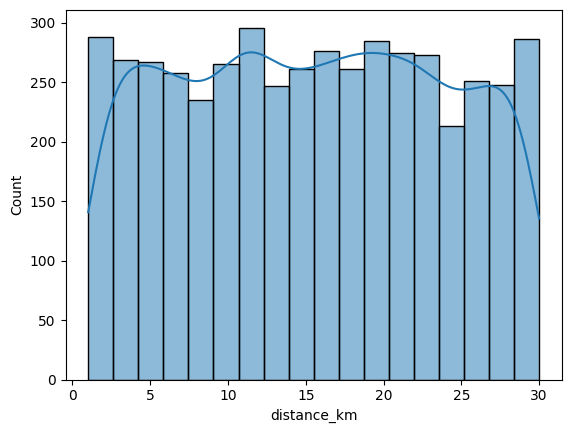

In [10]:
import seaborn as sns

print(rides['distance_km'].skew())

sns.histplot(rides['distance_km'], kde=True)

6.727131329074388


<Axes: xlabel='fare_amount', ylabel='Count'>

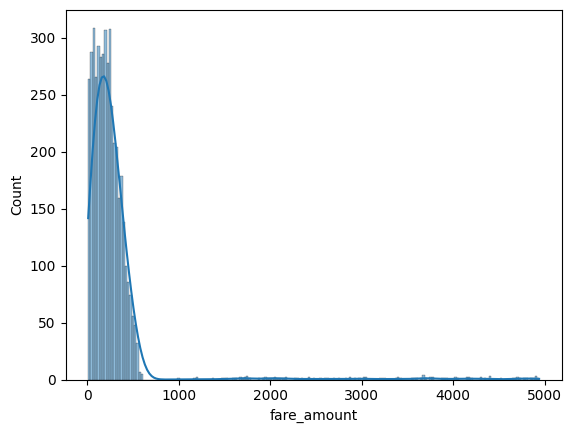

In [11]:
print(rides['fare_amount'].skew())

sns.histplot(rides['fare_amount'], kde=True)

In [12]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

data = imputer.fit_transform(rides[['distance_km']])

rides['distance_km'] = pd.DataFrame(data, columns=['distance_km'])

rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      5000 non-null   float64
 2   fare_amount      4523 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    4737 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [13]:
imputer = SimpleImputer(strategy="median")

data = imputer.fit_transform(rides[['fare_amount']])

rides['fare_amount'] = pd.DataFrame(data, columns=['fare_amount'])

rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      5000 non-null   float64
 2   fare_amount      5000 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    4737 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [14]:
imputer = SimpleImputer(strategy="most_frequent")

data = imputer.fit_transform(rides[['traffic_level']])

rides['traffic_level'] = pd.DataFrame(data, columns=['traffic_level'])

rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ride_id          5000 non-null   int64  
 1   distance_km      5000 non-null   float64
 2   fare_amount      5000 non-null   float64
 3   pickup_datetime  5000 non-null   object 
 4   traffic_level    5000 non-null   object 
 5   city             5000 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 234.5+ KB


In [15]:
rides['pickup_datetime'] = pd.to_datetime(rides['pickup_datetime'])

rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ride_id          5000 non-null   int64         
 1   distance_km      5000 non-null   float64       
 2   fare_amount      5000 non-null   float64       
 3   pickup_datetime  5000 non-null   datetime64[ns]
 4   traffic_level    5000 non-null   object        
 5   city             5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 234.5+ KB


In [16]:
rides.duplicated().sum()

np.int64(0)

In [17]:
rides.drop_duplicates(inplace=True)

## Exploratory Data Analysis (EDA)

In [18]:
# Univariate Analysis:
  # Analyze distribution of:
    # distance_km
    # fare_amount
    # traffic_level
# Bivariate Analysis:
  # Relationship between:
    # distance_km vs fare_amount
    # traffic_level vs fare_amount
# Multivariate Analysis:
  # Analyze combined effect of:
    # city + traffic + distance on fare
  # Identify patterns, trends, and anomalies

traffic_level
Low       1877
Medium    1565
High      1558
Name: count, dtype: int64


<Axes: xlabel='traffic_level', ylabel='count'>

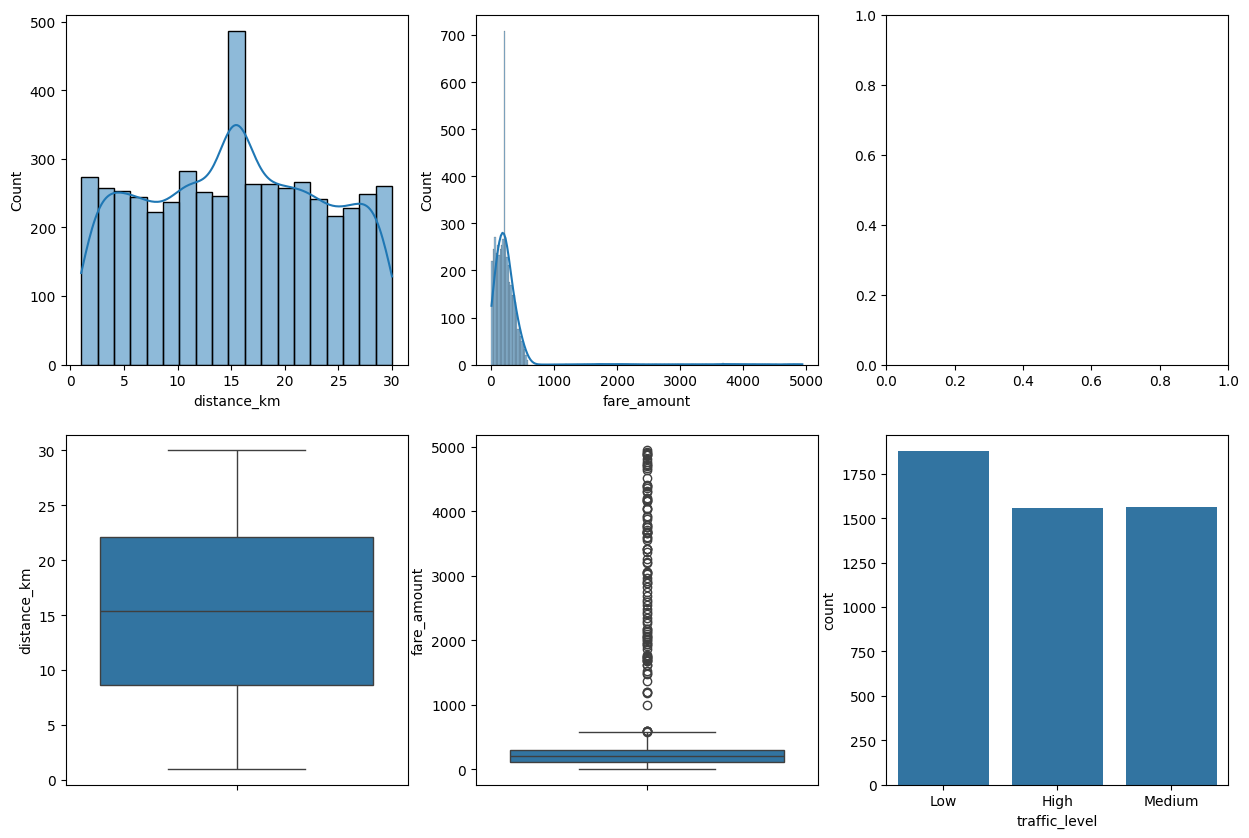

In [19]:
# Univariate Analysis:
  # Analyze distribution of:
    # distance_km
    # fare_amount
    # traffic_level

import matplotlib.pyplot as plt

_, axes = plt.subplots(2, 3, figsize=(15, 10))

print(rides['traffic_level'].value_counts())

sns.histplot(rides['distance_km'], kde=True, ax=axes[0, 0])
sns.histplot(rides['fare_amount'], kde=True, ax=axes[0, 1])

sns.boxplot(rides['distance_km'], ax=axes[1, 0])
sns.boxplot(rides['fare_amount'], ax=axes[1, 1])
sns.countplot(x=rides['traffic_level'], ax=axes[1, 2])

<Axes: xlabel='traffic_level', ylabel='fare_amount'>

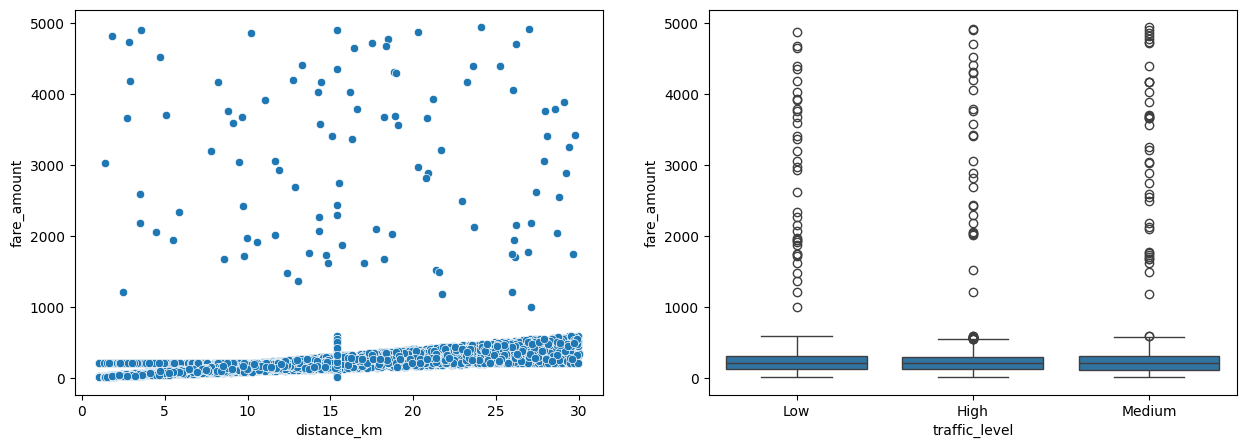

In [20]:
# Bivariate Analysis:
  # Relationship between:
    # distance_km vs fare_amount
    # traffic_level vs fare_amount

_, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(x=rides['distance_km'], y=rides['fare_amount'], ax=axes[0])
sns.boxplot(x=rides['traffic_level'], y=rides['fare_amount'], ax=axes[1])


In [21]:
dist_fare_corr = rides['distance_km'].corr(rides['fare_amount'])
dist_fare_corr

np.float64(0.23969317847116842)

In [22]:
# Multivariate Analysis:
  # Analyze combined effect of:
    # city + traffic + distance on fare
  # Identify patterns, trends, and anomalies

corr_matrix = rides[['distance_km', 'fare_amount']].corr()
corr_matrix

,distance_km,fare_amount
distance_km,1.000000,0.239693
fare_amount,0.239693,1.000000


In [23]:
rides['traffic_level'].value_counts()

,count
traffic_level,
Low,1877
Medium,1565
High,1558


<Axes: >

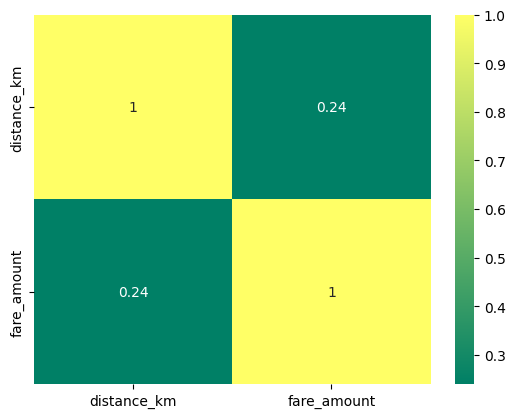

In [24]:
sns.heatmap(corr_matrix, annot=True, cmap="summer")

## Missing Value Treatment

In [25]:
# Apply:
  # Simple Imputer
  # Most Frequent Imputation
  # KNN Imputer
# Compare results of different techniques

In [26]:
new_rides = pd.read_csv("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_rides.csv")
new_drivers = pd.read_json("/content/drive/MyDrive/Subject-wise Content | Materials/Programming Materials/AI ML/RNW/7. Data Preprocessing & AI ML/Materials/day 15 & 16 - Live Project - Revision/resources/smartride_drivers.json")

In [27]:
new_rides.isnull().sum()

,0
ride_id,0
distance_km,246
fare_amount,477
pickup_datetime,0
traffic_level,263
city,0


In [28]:
new_drivers.isnull().sum()

,0
driver_id,0
experience,0
rating,0


In [29]:
new_rides[['distance_km', 'fare_amount']].describe()

,distance_km,fare_amount
count,4754.000000,4523.000000
mean,15.396346,281.926741
std,8.378683,481.496319
min,1.010000,8.780000
25%,8.152500,109.435000
50%,15.420000,206.070000
75%,22.407500,317.225000
max,30.000000,4939.830000


In [30]:
from sklearn.impute import SimpleImputer, KNNImputer

simple_mean_imputer = SimpleImputer(strategy="mean")
mean_data = simple_mean_imputer.fit_transform(rides[['distance_km']])
df1 = pd.DataFrame(mean_data, columns=['distance_km'])

simple_median_imputer = SimpleImputer(strategy="median")
median_data = simple_median_imputer.fit_transform(rides[['fare_amount']])
df2 = pd.DataFrame(median_data, columns=['fare_amount'])

simple_mf_imputer = SimpleImputer(strategy="most_frequent")
mf_data = simple_mf_imputer.fit_transform(rides[['traffic_level']])
df3 = pd.DataFrame(mf_data, columns=['traffic_level'])

imputed_df = pd.concat([df1, df2, df3], axis=1)
imputed_df

,distance_km,fare_amount,traffic_level
0,11.930000,135.18,Low
1,11.050000,180.06,High
2,1.480000,19.51,Low
3,14.810000,147.11,High
4,22.650000,436.55,High
...,...,...,...
4995,2.220000,33.03,Low
4996,28.370000,230.77,Medium
4997,12.970000,252.67,Medium
4998,10.410000,197.99,Low


In [31]:
imputed_df[['distance_km', 'fare_amount']].describe()

,distance_km,fare_amount
count,5000.000000,5000.000000
mean,15.396346,274.690008
std,8.169925,458.490515
min,1.010000,8.780000
25%,8.630000,118.717500
50%,15.396346,206.070000
75%,22.080000,302.882500
max,30.000000,4939.830000


In [32]:
knn_imputer = KNNImputer(n_neighbors=5)
knn_data = knn_imputer.fit_transform(new_rides[['distance_km', 'fare_amount']])

knn_data_df = pd.DataFrame(knn_data, columns=['distance_km', 'fare_amount'])
knn_data_df

,distance_km,fare_amount
0,11.930,135.18
1,11.050,180.06
2,1.480,19.51
3,14.810,147.11
4,22.650,436.55
...,...,...
4995,2.220,33.03
4996,28.370,230.77
4997,12.970,252.67
4998,10.410,197.99


In [33]:
knn_data_df[['distance_km', 'fare_amount']].describe()

,distance_km,fare_amount
count,5000.000000,5000.000000
mean,15.361061,281.958823
std,8.359259,464.343062
min,1.010000,8.780000
25%,8.117500,110.517500
50%,15.396346,207.820000
75%,22.370000,319.657500
max,30.000000,4939.830000


## Outlier Detection & Handling

In [34]:
# Detect outliers using:
  # Z-score method
  # IQR method
# Apply:
  # Percentile method
  # Winsorization
# Analyze impact before and after treatment

<Axes: ylabel='distance_km'>

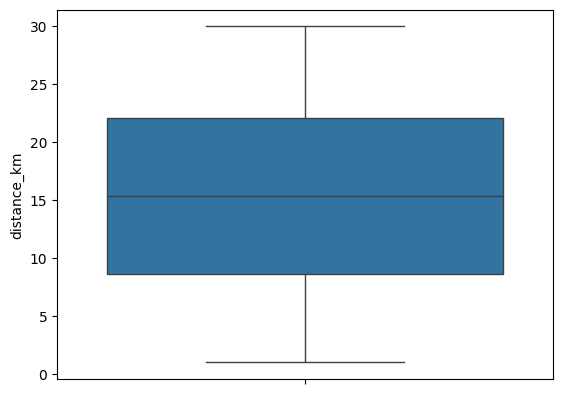

In [35]:
sns.boxplot(rides['distance_km'])

<Axes: ylabel='fare_amount'>

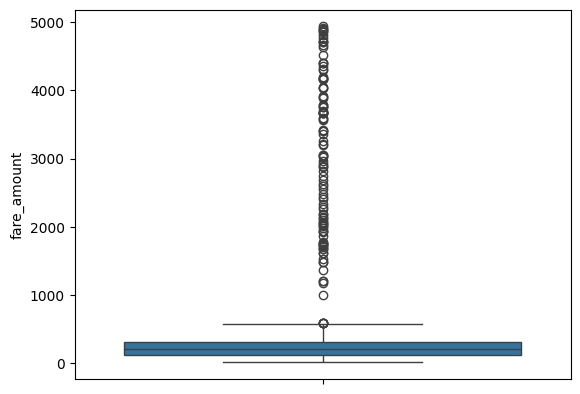

In [36]:
sns.boxplot(rides['fare_amount'])

In [37]:
mean = rides['fare_amount'].mean()
std = rides['fare_amount'].std()

rides['z_score'] = (rides['fare_amount'] - mean) / std

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [38]:
rides['z_score'].describe()

,z_score
count,5.000000e+03
mean,-7.673862e-17
std,1.000000e+00
min,-5.799684e-01
25%,-3.401870e-01
50%,-1.496651e-01
75%,6.148980e-02
max,1.017500e+01


In [39]:
outliers = rides[rides['z_score'].abs() > 3]
outliers

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
221,222,9.130000,3595.03,2026-02-08 20:46:54,Low,Bangalore,7.241895
235,236,12.880000,2687.96,2026-03-30 19:46:54,High,Bangalore,5.263511
298,299,15.396346,2435.55,2026-02-08 13:46:54,High,Surat,4.712987
448,449,26.930000,1774.09,2026-03-18 06:46:54,Medium,Mumbai,3.270297
487,488,21.190000,3920.18,2026-03-28 06:46:54,Low,Mumbai,7.951070
...,...,...,...,...,...,...,...
4818,4819,18.980000,4298.84,2026-03-27 08:46:54,High,Bangalore,8.776954
4877,4878,29.100000,3884.49,2026-03-31 07:46:54,Medium,Delhi,7.873227
4896,4897,17.490000,4710.57,2026-02-24 16:46:54,Medium,Delhi,9.674966
4908,4909,16.310000,3363.86,2026-02-25 23:46:54,Low,Surat,6.737697


In [40]:
# Outliers removed
final_data = rides[~(rides['z_score'].abs() > 3)]
final_data

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [41]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [42]:
Q1 = rides['fare_amount'].quantile(0.25)
Q3 = rides['fare_amount'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

print(lower_fence, upper_fence)

outliers = rides[(rides['fare_amount'] < lower_fence) | (rides['fare_amount'] > upper_fence)]
outliers

-157.53 579.13


,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
221,222,9.130000,3595.03,2026-02-08 20:46:54,Low,Bangalore,7.241895
235,236,12.880000,2687.96,2026-03-30 19:46:54,High,Bangalore,5.263511
298,299,15.396346,2435.55,2026-02-08 13:46:54,High,Surat,4.712987
330,331,13.040000,1369.38,2026-03-31 05:46:54,Low,Ahmedabad,2.387596
432,433,15.396346,586.26,2026-02-16 20:46:54,High,Mumbai,0.679556
...,...,...,...,...,...,...,...
4818,4819,18.980000,4298.84,2026-03-27 08:46:54,High,Bangalore,8.776954
4877,4878,29.100000,3884.49,2026-03-31 07:46:54,Medium,Delhi,7.873227
4896,4897,17.490000,4710.57,2026-02-24 16:46:54,Medium,Delhi,9.674966
4908,4909,16.310000,3363.86,2026-02-25 23:46:54,Low,Surat,6.737697


In [43]:
final_data = rides[~((rides['fare_amount'] < lower_fence) | (rides['fare_amount'] > upper_fence))]
final_data

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [44]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [45]:
# percentile method

lower_pct = 0.05
upper_pct = 0.95

lower_bound = rides['fare_amount'].quantile(lower_pct)
upper_bound = rides['fare_amount'].quantile(upper_pct)

outliers = rides[(rides['fare_amount'] < lower_bound) | (rides['fare_amount'] > upper_bound)]
outliers

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
9,10,2.00,17.34,2026-02-12 22:46:54,Low,Mumbai,-0.561298
44,45,1.51,28.52,2026-02-10 23:46:54,Low,Ahmedabad,-0.536914
84,85,2.75,32.37,2026-02-19 15:46:54,High,Bangalore,-0.528517
93,94,1.60,27.05,2026-03-13 00:46:54,Medium,Ahmedabad,-0.540120
...,...,...,...,...,...,...,...
4955,4956,2.75,3665.47,2026-02-19 03:46:54,Medium,Delhi,7.395529
4969,4970,1.53,15.31,2026-03-29 10:46:54,High,Mumbai,-0.565726
4971,4972,1.93,30.45,2026-03-18 12:46:54,Medium,Delhi,-0.532705
4988,4989,27.90,548.57,2026-03-21 05:46:54,Low,Surat,0.597351


In [46]:
final_data = rides[~((rides['fare_amount'] < lower_bound) | (rides['fare_amount'] > upper_bound))]
final_data

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
5,6,2.960000,47.42,2026-02-13 17:46:54,Low,Delhi,-0.495692
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [47]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028
...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288


In [48]:
# winsorization
lower = rides['fare_amount'].quantile(0.05)
upper = rides['fare_amount'].quantile(0.95)

rides['fare_amount_clipped'] = rides['fare_amount'].clip(lower=lower, upper=upper)

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,z_score,fare_amount_clipped
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,-0.304281,135.1800
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,-0.206395,180.0600
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,-0.556566,33.0185
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,-0.278261,147.1100
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,0.353028,436.5500
...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,-0.527077,33.0300
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,-0.095793,230.7700
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,-0.048027,252.6700
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,-0.167288,197.9900


In [49]:
rides.drop(columns=['z_score', 'fare_amount_clipped'], inplace=True)

## Feature Engineering

In [50]:
# Convert pickup_datetime and extract:
  # Hour
  # Day
  # Month
# Create new features:
  # Peak hour indicator
  # Distance category (Short / Medium / Long)

In [51]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad
...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai


In [52]:
rides['pickup_datetime'] = pd.to_datetime(rides['pickup_datetime'])

rides['day'] = rides['pickup_datetime'].dt.day
rides['month'] = rides['pickup_datetime'].dt.month
rides['hour'] = rides['pickup_datetime'].dt.hour

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1
...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19


In [53]:
rides['hour'].value_counts().sort_values(ascending=False)

,count
hour,
22,244
20,225
19,223
6,223
10,219
16,219
5,214
13,213
14,212


In [54]:
peak_hours = rides['hour'].value_counts().sort_values(ascending=False).head().index
peak_hours

Index([22, 20, 19, 6, 10], dtype='int32', name='hour')

In [55]:
rides['is_peak_hour'] = rides['hour'].apply(lambda x: 'peak_hour' if x in peak_hours else 'normal_hour')
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour
...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour


In [56]:
rides['distance_km'].value_counts().sort_values(ascending=False)

,count
distance_km,
15.396346,246
18.130000,9
13.960000,8
5.120000,7
22.350000,7
...,...
28.370000,1
17.280000,1
12.440000,1


In [57]:
rides['distance_km'].describe()

,distance_km
count,5000.000000
mean,15.396346
std,8.169925
min,1.010000
25%,8.630000
50%,15.396346
75%,22.080000
max,30.000000


In [58]:
def dest_cat(km):
  if km <= 5:
    return 'short'
  elif km <= 15:
    return 'medium'
  else:
    return 'long'

rides['distance_category'] = rides['distance_km'].apply(dest_cat)

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium


## Handling Mixed Variables

In [59]:
# Separate numerical and categorical features (if any mixed variable available)
# Properly handle datetime features
# Ensure dataset is ready for further analysis

In [60]:
rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long
...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium


In [61]:
rides.dtypes

,0
ride_id,int64
distance_km,float64
fare_amount,float64
pickup_datetime,datetime64[ns]
traffic_level,object
city,object
day,int32
month,int32
hour,int32
is_peak_hour,object


## Encoding Categorical Data

In [62]:
# Apply:
# Label Encoding
# One Hot Encoding
# Ordinal Encoding (for traffic_level)

In [63]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long


In [64]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder

label_encoder = LabelEncoder()
city_label_encoded = label_encoder.fit_transform(rides['city'])

rides['city_label_encoded'] = pd.DataFrame(city_label_encoded, columns=['city_label_encoded'])

print(label_encoder.classes_)

rides.head()

['Ahmedabad' 'Bangalore' 'Delhi' 'Mumbai' 'Surat']


,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0


In [65]:
ordinal_encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
traffic_level_ord_encoded = ordinal_encoder.fit_transform(rides[['traffic_level']])

rides['traffic_level_ord_encoded'] = pd.DataFrame(traffic_level_ord_encoded, columns=['traffic_level_ord_encoded'])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0


In [66]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
is_peak_hour_ohe_array = ohe.fit_transform(rides[['is_peak_hour']])

is_peak_hour_df = pd.DataFrame(is_peak_hour_ohe_array, columns=ohe.get_feature_names_out(['is_peak_hour']))

rides = pd.concat([rides, is_peak_hour_df], axis=1)

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0,1.0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0,0.0,1.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0,0.0,1.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0,0.0,1.0


## Numerical Feature Transformation

In [67]:
# Apply:
    # Binning (Discretization)
    # Quantile Binning
    # K-Means Binning
    # Binarization

In [68]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0


In [69]:
from sklearn.preprocessing import KBinsDiscretizer

kbd = KBinsDiscretizer(n_bins=3, strategy="uniform", encode="ordinal")
rides['distance_km_binned'] = kbd.fit_transform(rides[['distance_km']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour,distance_km_binned
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0,1.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0,1.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0,1.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0,1.0,0.0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0,0.0,1.0,2.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0,0.0,1.0,1.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0,0.0,1.0,0.0


In [70]:
kbdq = KBinsDiscretizer(n_bins=3, strategy="quantile", encode="ordinal")
rides['distance_km_binned_q'] = kbdq.fit_transform(rides[['distance_km']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour,distance_km_binned,distance_km_binned_q
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0,1.0,1.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0,1.0,0.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0,0.0,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0,1.0,1.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0,1.0,0.0,0.0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0,0.0,1.0,2.0,2.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0,0.0,1.0,1.0,1.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0,0.0,1.0,0.0,0.0


In [71]:
kbd_kmeans = KBinsDiscretizer(n_bins=3, strategy="kmeans", encode="ordinal")
rides['distance_km_binned_kmeans'] = kbd_kmeans.fit_transform(rides[['distance_km']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour,distance_km_binned,distance_km_binned_q,distance_km_binned_kmeans
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0,1.0,1.0,1.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0,1.0,0.0,1.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0,0.0,0.0,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0,1.0,1.0,1.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0,1.0,0.0,0.0,0.0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0,0.0,1.0,2.0,2.0,2.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0,0.0,1.0,1.0,1.0,1.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0,0.0,1.0,0.0,0.0,0.0


In [72]:
from sklearn.preprocessing import Binarizer

binarizer = Binarizer(threshold=15)
rides['distance_km_binarized'] = binarizer.fit_transform(rides[['distance_km']])

rides

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour,distance_km_binned,distance_km_binned_q,distance_km_binned_kmeans,distance_km_binarized
0,1,11.930000,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0,1.0,1.0,1.0,0.0
1,2,11.050000,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0,1.0,0.0,1.0,0.0
2,3,1.480000,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,14.810000,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0,1.0,1.0,1.0,0.0
4,5,22.650000,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0,2.0,2.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,2.220000,33.03,2026-04-06 17:46:54,Low,Ahmedabad,6,4,17,normal_hour,short,0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4996,4997,28.370000,230.77,2026-03-29 10:46:54,Medium,Delhi,29,3,10,peak_hour,long,2,1.0,0.0,1.0,2.0,2.0,2.0,1.0
4997,4998,12.970000,252.67,2026-03-16 20:46:54,Medium,Mumbai,16,3,20,peak_hour,medium,3,1.0,0.0,1.0,1.0,1.0,1.0,0.0
4998,4999,10.410000,197.99,2026-03-31 19:46:54,Low,Mumbai,31,3,19,peak_hour,medium,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## Feature Scaling

In [73]:
# Apply:
  # Standardization
  # Normalization
    # MinMax Scaling
    # Robust Scaling
# Compare the effects of each scaling method

In [74]:
rides.head()

,ride_id,distance_km,fare_amount,pickup_datetime,traffic_level,city,day,month,hour,is_peak_hour,distance_category,city_label_encoded,traffic_level_ord_encoded,is_peak_hour_normal_hour,is_peak_hour_peak_hour,distance_km_binned,distance_km_binned_q,distance_km_binned_kmeans,distance_km_binarized
0,1,11.93,135.18,2026-02-05 19:46:54,Low,Bangalore,5,2,19,peak_hour,medium,1,0.0,0.0,1.0,1.0,1.0,1.0,0.0
1,2,11.05,180.06,2026-02-27 06:46:54,High,Delhi,27,2,6,peak_hour,medium,2,2.0,0.0,1.0,1.0,0.0,1.0,0.0
2,3,1.48,19.51,2026-02-17 07:46:54,Low,Bangalore,17,2,7,normal_hour,short,1,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,4,14.81,147.11,2026-03-19 10:46:54,High,Bangalore,19,3,10,peak_hour,medium,1,2.0,0.0,1.0,1.0,1.0,1.0,0.0
4,5,22.65,436.55,2026-03-01 01:46:54,High,Ahmedabad,1,3,1,normal_hour,long,0,2.0,1.0,0.0,2.0,2.0,2.0,1.0


In [78]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
data = std_scaler.fit_transform(rides[['fare_amount']])
rides['fare_amount_std_scaled'] = pd.DataFrame(data, columns=[['fare_amount_std_scaled']])

rides['fare_amount_std_scaled'].describe()

,fare_amount_std_scaled
count,5.000000e+03
mean,-7.815970e-17
std,1.000100e+00
min,-5.800264e-01
25%,-3.402210e-01
50%,-1.496800e-01
75%,6.149595e-02
max,1.017602e+01


In [79]:
from sklearn.preprocessing import MinMaxScaler

mm_scaler = MinMaxScaler()
data = mm_scaler.fit_transform(rides[['fare_amount']])
rides['fare_amount_mm_scaled'] = pd.DataFrame(data, columns=[['fare_amount_mm_scaled']])

rides['fare_amount_mm_scaled'].describe()

,fare_amount_mm_scaled
count,5000.000000
mean,0.053926
std,0.092980
min,0.000000
25%,0.022295
50%,0.040010
75%,0.059643
max,1.000000


In [80]:
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()
data = rob_scaler.fit_transform(rides[['fare_amount']])
rides['fare_amount_rob_scaled'] = pd.DataFrame(data, columns=[['fare_amount_rob_scaled']])

rides['fare_amount_rob_scaled'].describe()

,fare_amount_rob_scaled
count,5000.000000
mean,0.372601
std,2.489564
min,-1.071268
25%,-0.474317
50%,0.000000
75%,0.525683
max,25.703907


## Advanced Feature Transformation

In [84]:
# Apply:
  # FunctionTransformer
    # Log
    # Reciprocal
    # Square root

# Apply:
  # PowerTransformer
    # Box-Cox
    # Yeo-Johnson

# Use ColumnTransformer to create a preprocessing pipeline

In [96]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('log_fare_amount', FunctionTransformer(func=np.log1p), ['fare_amount']),
        ('reciprocal_fare_amount', FunctionTransformer(func=np.reciprocal), ['fare_amount']),
        ('sqrt_fare_amount', FunctionTransformer(func=np.sqrt), ['fare_amount']),
    ],
    remainder='drop'
)

data = ct.fit_transform(rides)

transformed_cols = ['log_fare_amount', 'reciprocal_fare_amount', 'sqrt_fare_amount']
transformed_df = pd.DataFrame(data, columns=transformed_cols)
transformed_df

,log_fare_amount,reciprocal_fare_amount,sqrt_fare_amount
0,4.913978,0.007398,11.626693
1,5.198828,0.005554,13.418644
2,3.020913,0.051256,4.417013
3,4.997955,0.006798,12.128891
4,6.081191,0.002291,20.893779
...,...,...,...
4995,3.527242,0.030276,5.747173
4996,5.445746,0.004333,15.191116
4997,5.536034,0.003958,15.895597
4998,5.293255,0.005051,14.070892


In [103]:
rides['fare_amount'].describe()

,fare_amount
count,5000.000000
mean,274.690008
std,458.490515
min,8.780000
25%,118.717500
50%,206.070000
75%,302.882500
max,4939.830000


In [105]:
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer

ct2 = ColumnTransformer(
    transformers=[
        ('boxcox_fare_amount', PowerTransformer(method='box-cox'), ['fare_amount']),
        ('yeojohn_fare_amount', PowerTransformer(method='yeo-johnson'), ['fare_amount']),
    ],
    remainder='drop'
)

data = ct2.fit_transform(rides)

transformed_cols = ['boxcox_fare_amount', 'yeojohn_fare_amount']
transformed_df2 = pd.DataFrame(data, columns=transformed_cols)
transformed_df2

,boxcox_fare_amount,yeojohn_fare_amount
0,-0.344310,-0.345644
1,-0.019655,-0.019624
2,-2.419782,-2.415947
3,-0.249014,-0.249934
4,1.012874,1.015388
...,...,...
4995,-1.874823,-1.878242
4996,0.265088,0.266154
4997,0.370003,0.371396
4998,0.088864,0.089314
